# 03 — Feature Extraction & Engineering





---
### Design decisions
- `StandardScaler` is **fitted on `X_train` only** then applied to both splits — no data leakage
- `SMOTE` is applied **after scaling, on training set only** — test set is never touched
- Hanning window is applied inside `frequency_domain_features()` in `features.py` — no raw FFT leakage
- `dominant_freq` is kept but flagged as a weak feature based on EDA (all fault peaks within 140 Hz of each other)

---
## 1. Setup & Imports

In [1]:
import sys
import os
import joblib

sys.path.append(os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif
from matplotlib.patches import Patch

from imblearn.over_sampling import SMOTE
    
from features import extract_features, get_feature_names
from loader import get_label_name

print('✓ All imports successful')

✓ All imports successful


In [2]:
plt.rcParams['figure.dpi']= 120
plt.rcParams['figure.facecolor'] = '#0f0f11'
plt.rcParams['axes.facecolor'] = '#0f0f11'
plt.rcParams['axes.edgecolor'] = '#2a2a30'
plt.rcParams['axes.labelcolor']  = '#ccccdd'
plt.rcParams['xtick.color'] = '#7a7a8e'
plt.rcParams['ytick.color'] = '#7a7a8e'
plt.rcParams['text.color']  = '#e8e8f0'
plt.rcParams['grid.color'] = '#1e2330'
plt.rcParams['grid.linewidth']   = 0.6

CLASS_COLORS = {
    0: '#4fbe97',
    1: '#3d6aff',
    2: '#f0a147',
    3: '#c17cff',
}
CLASS_NAMES = {0: 'Normal', 1: 'Inner Race', 2: 'Ball', 3: 'Outer Race'}

In [3]:
PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
REPORTS_DIR   = os.path.join(PROJECT_ROOT, 'reports')
FS = 12000
RANDOM_SEED = 42

os.makedirs(REPORTS_DIR, exist_ok=True)

FEATURE_NAMES = get_feature_names()  

print(f'Feature set ({len(FEATURE_NAMES)} features):')
print(f'  Time-domain  (9): {FEATURE_NAMES[:9]}')
print(f'  Freq-domain  (7): {FEATURE_NAMES[9:]}')

Feature set (16 features):
  Time-domain  (9): ['rms', 'kurtosis', 'crest_factor', 'skewness', 'peak', 'peak_to_peak', 'std', 'mean_abs', 'shape_factor']
  Freq-domain  (7): ['dominant_freq', 'spectral_energy', 'spectral_entropy', 'spectral_mean', 'spectral_std', 'band_energy_100_4000', 'band_energy_4000_6000']


---
## 2. Load Preprocessed Windows



In [4]:
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

print('── Loaded arrays ────────────────────────────────────────')
print(f'  X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'  X_test  : {X_test.shape}    y_test  : {y_test.shape}')
print()
print('  Train class distribution:')
for label, count in sorted(Counter(y_train).items()):
    print(f'    {label} {CLASS_NAMES[label]:<12}: {count:>5,} windows  ({count/len(y_train)*100:.1f}%)')
print()
print('  Test class distribution:')
for label, count in sorted(Counter(y_test).items()):
    print(f'    {label} {CLASS_NAMES[label]:<12}: {count:>5,} windows  ({count/len(y_test)*100:.1f}%)')

── Loaded arrays ────────────────────────────────────────
  X_train : (2647, 1024)   y_train : (2647,)
  X_test  : (662, 1024)    y_test  : (662,)

  Train class distribution:
    0 Normal      :   755 windows  (28.5%)
    1 Inner Race  :   756 windows  (28.6%)
    2 Ball        :   756 windows  (28.6%)
    3 Outer Race  :   380 windows  (14.4%)

  Test class distribution:
    0 Normal      :   189 windows  (28.5%)
    1 Inner Race  :   189 windows  (28.5%)
    2 Ball        :   189 windows  (28.5%)
    3 Outer Race  :    95 windows  (14.4%)


---
## 3. Feature Extraction

Extract all 16 features from every window in both train and test sets.  
Each window (1024 samples) → 1 row of 16 floats.

> **Note:** `frequency_domain_features()` in `features.py` applies a Hanning window  
> before FFT — spectral leakage is already handled inside the function.

In [5]:
def extract_feature_matrix(windows: np.ndarray,
                            labels: np.ndarray,
                            fs: int = 12000,
                            split_name: str = 'set') -> pd.DataFrame:
    
    rows = []
    n    = len(windows)

    for i, window in enumerate(windows):
        feats = extract_features(window, fs=fs)
        feats['label'] = labels[i]
        rows.append(feats)

        if (i + 1) % 500 == 0 or (i + 1) == n:
            print(f'  {split_name}: {i+1:>5}/{n} windows processed', end='\r')

    print()
    return pd.DataFrame(rows)


print('Extracting features from training windows...')
df_train = extract_feature_matrix(X_train, y_train, fs=FS, split_name='Train')
print(f'✓ Train feature matrix: {df_train.shape[0]:,} rows × {df_train.shape[1]} columns')

print()
print('Extracting features from test windows...')
df_test = extract_feature_matrix(X_test, y_test, fs=FS, split_name='Test')
print(f'✓ Test feature matrix : {df_test.shape[0]:,} rows × {df_test.shape[1]} columns')

Extracting features from training windows...
  Train:  2647/2647 windows processed
✓ Train feature matrix: 2,647 rows × 17 columns

Extracting features from test windows...
  Test:   662/662 windows processed
✓ Test feature matrix : 662 rows × 17 columns


In [6]:
F_train = df_train[FEATURE_NAMES].values
F_test  = df_test[FEATURE_NAMES].values

# Quick NaN / Inf check — corrupted windows would produce these
for name, arr in [('F_train', F_train), ('F_test', F_test)]:
    n_nan = np.isnan(arr).sum()
    n_inf = np.isinf(arr).sum()
    status = '✓ clean' if (n_nan + n_inf) == 0 else f'⚠ NaN={n_nan}, Inf={n_inf}'
    print(f'  {name}: {status}')

print()
print('First 3 rows of training feature matrix (unscaled):')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
print(df_train[FEATURE_NAMES].head(3).to_string())

  F_train: ✓ clean
  F_test: ✓ clean

First 3 rows of training feature matrix (unscaled):
     rms  kurtosis  crest_factor  skewness   peak  peak_to_peak    std  mean_abs  shape_factor  dominant_freq  spectral_energy  spectral_entropy  spectral_mean  spectral_std  band_energy_100_4000  band_energy_4000_6000
0 0.6515   16.3804        8.7288    0.1139 5.6867       10.6124 0.6515    0.3284        1.9835      3515.6250       47851.5645            4.2039         4.8497        8.3522                0.9933                 0.0067
1 0.4492    4.1432        5.0275    0.1531 2.2583        4.2601 0.4492    0.3090        1.4537      2906.2500       43250.7932            4.1706         4.5527        7.9739                0.9980                 0.0019
2 0.8521    0.1629        3.3218    0.0490 2.8305        5.4391 0.8521    0.6715        1.2689       632.8125      131975.7888            4.4114         8.7088       13.4692                0.9953                 0.0047


---
## 4. Feature Sanity Check — Per-Class Statistics



In [7]:
df_all = pd.concat([df_train, df_test], ignore_index=True)

df_grouped = df_all.groupby('label')[FEATURE_NAMES].mean().round(4)
df_grouped.index = [CLASS_NAMES[i] for i in df_grouped.index]

print('── Mean Feature Values per Class (unscaled) ─────────────────────────')
print(df_grouped.T.to_string())
print()

sep_ratios = {}
for feat in FEATURE_NAMES:
    vals = df_grouped[feat]
    ratio = vals.max() / (vals.min() + 1e-10)
    sep_ratios[feat] = round(ratio, 2)

sep_df = pd.DataFrame.from_dict(sep_ratios, orient='index',
                                 columns=['max/min class mean ratio'])
sep_df = sep_df.sort_values('max/min class mean ratio', ascending=False)

print('── Separation Ratio (max class mean / min class mean) ───────────────')
print('   Higher = feature varies more between classes = more discriminative')
print()
for feat, row in sep_df.iterrows():
    ratio = row['max/min class mean ratio']
    bar   = '█' * min(int(ratio / 5), 30)
    flag  = '  ← weak' if ratio < 2.0 else ''
    print(f'  {feat:<25}: {ratio:>8.2f}x  {bar}{flag}')

── Mean Feature Values per Class (unscaled) ─────────────────────────
                        Normal  Inner Race        Ball  Outer Race
rms                     0.0650      0.4336      0.6041      0.5714
kurtosis               -0.1080      6.2931      1.2134     10.6466
crest_factor            3.2203      5.4823      3.9946      6.2558
skewness               -0.1745      0.1330      0.0127      0.0481
peak                    0.2095      2.0290      2.2738      3.5543
peak_to_peak            0.3875      3.8130      4.4315      6.8612
std                     0.0650      0.4336      0.6040      0.5714
mean_abs                0.0521      0.3169      0.4586      0.3220
shape_factor            1.2477      1.4523      1.3101      1.7971
dominant_freq         533.6624   2639.1741   2952.6786   3212.0230
spectral_energy       834.1636  49652.7539 202956.7126  64804.8065
spectral_entropy        3.6036      4.4443      4.0927      4.1891
spectral_mean           0.5051      4.5551      5.2276     

---
## 5. Feature Distribution Boxplots



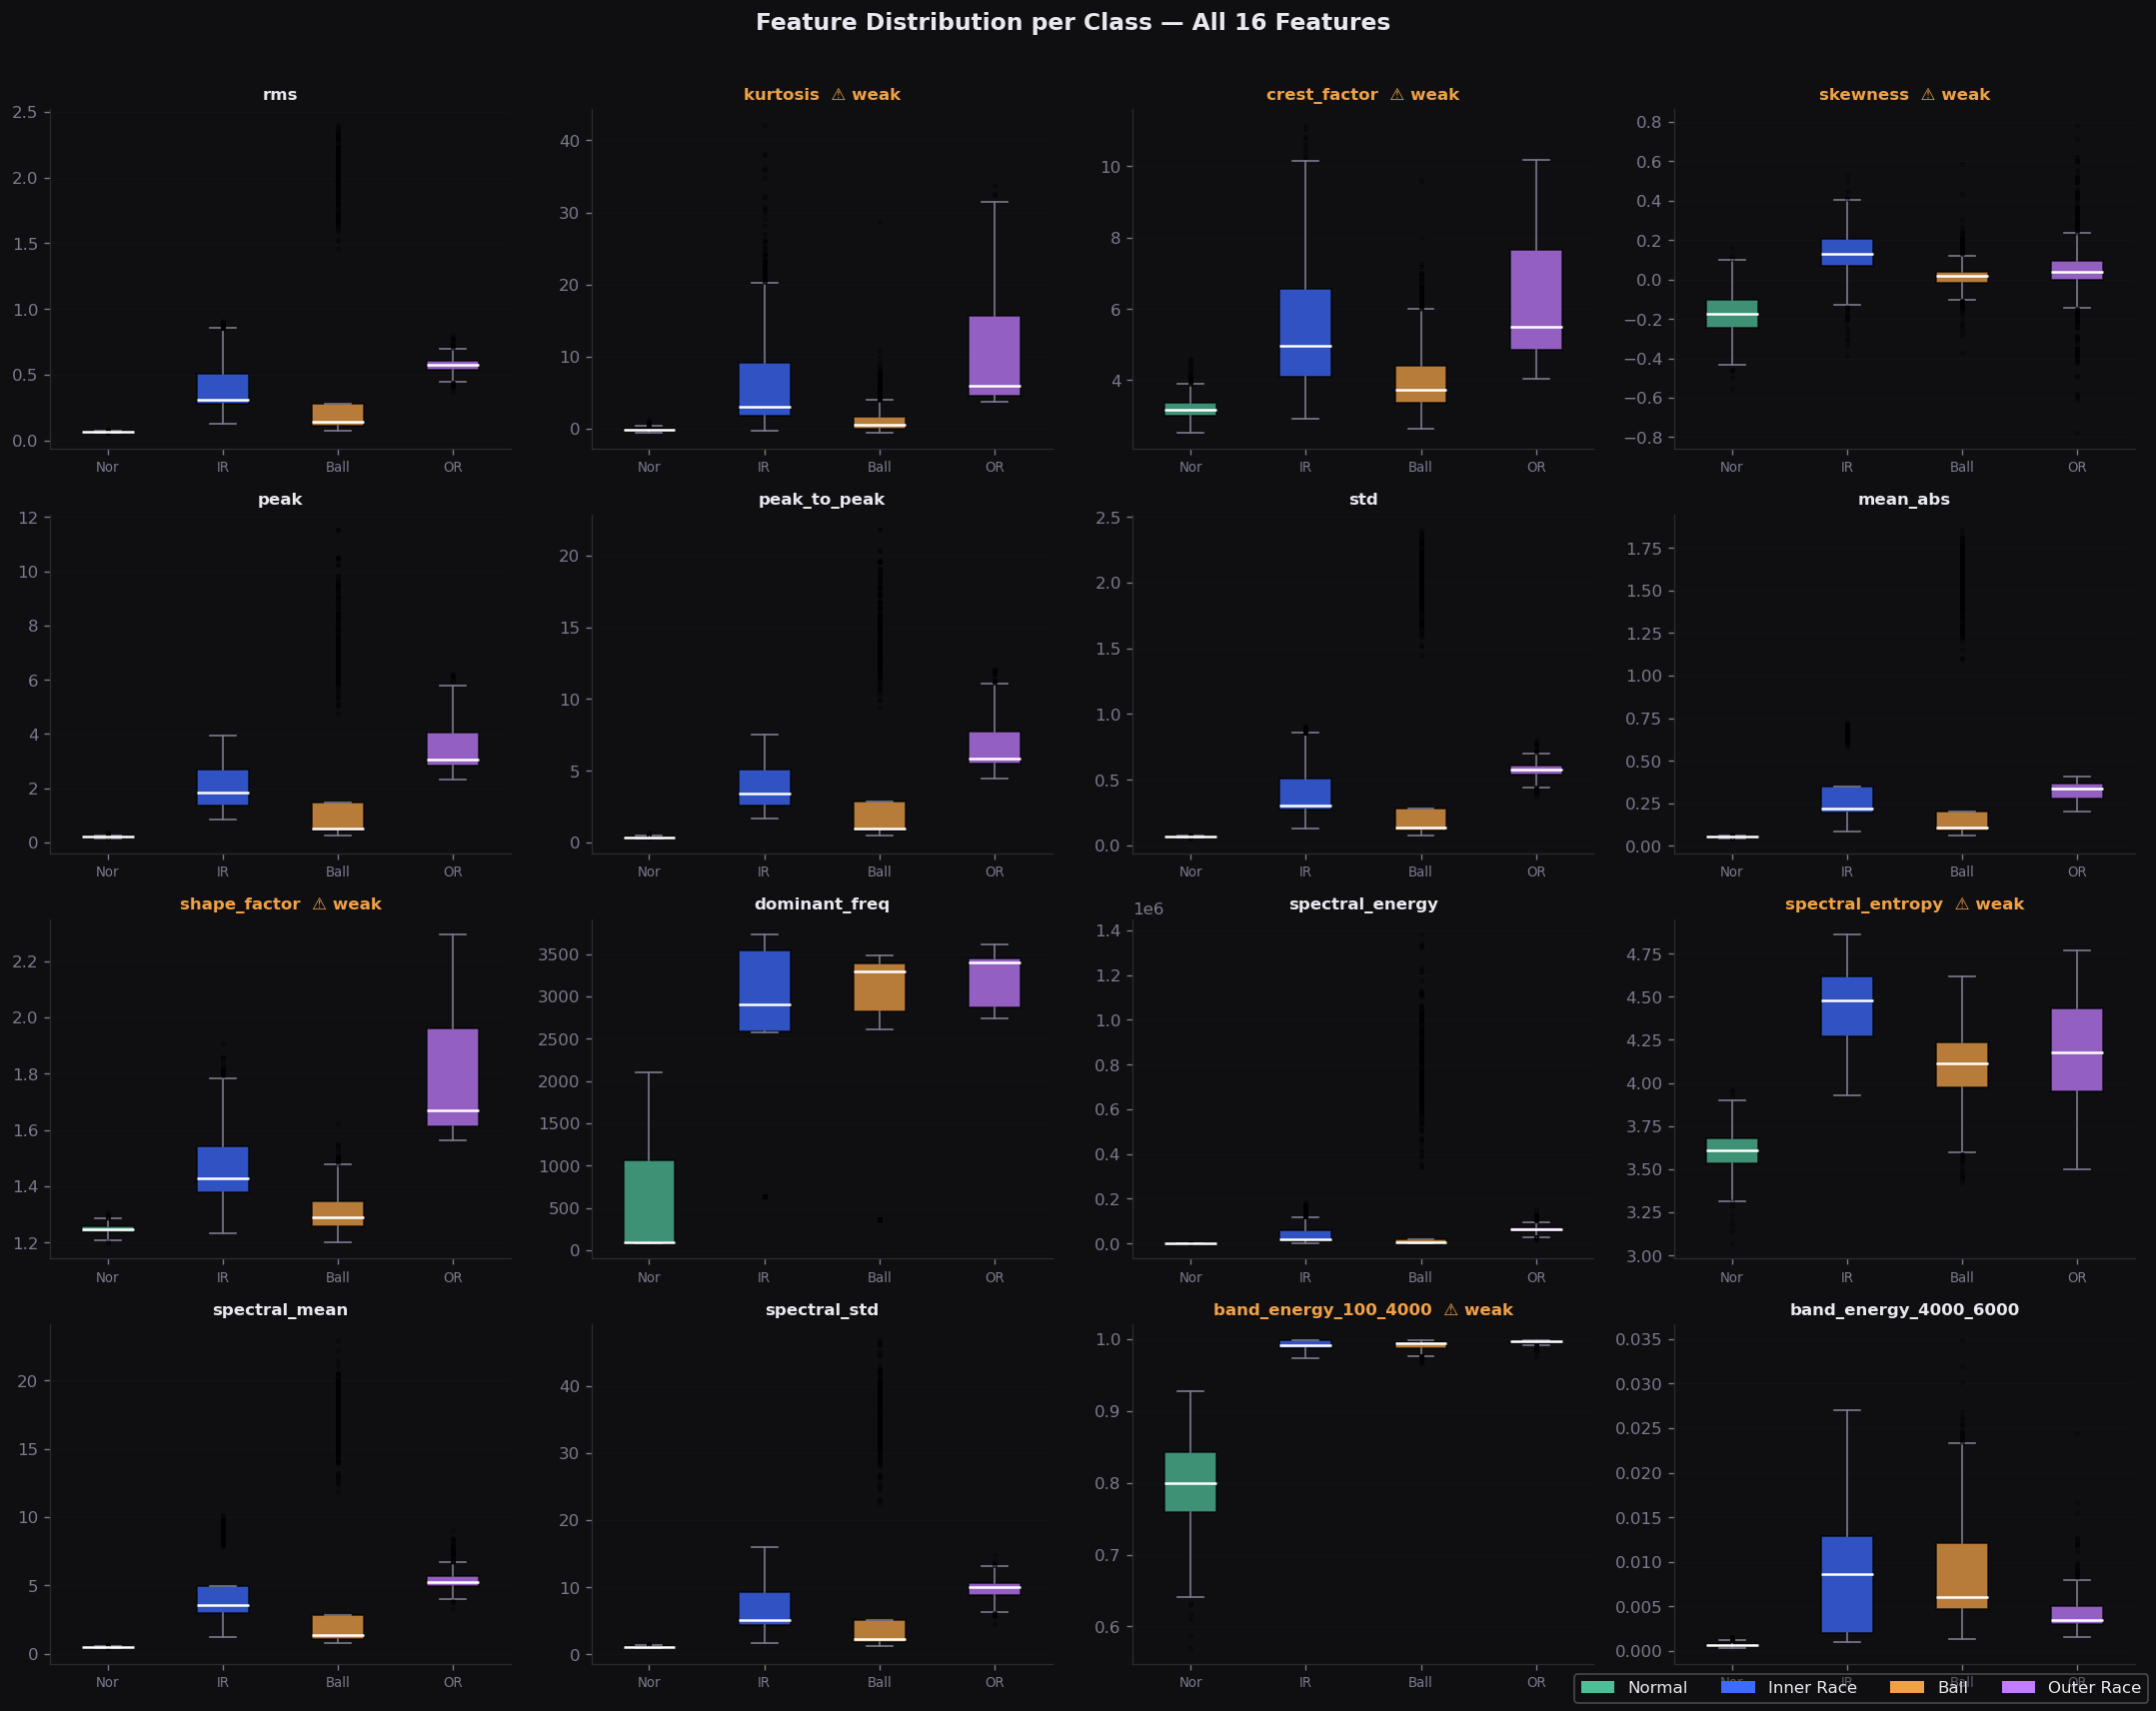

Saved → reports/13_feature_boxplots.png

Reading guide:
  Good feature  — boxes for each class do NOT overlap, tight IQR
  Weak feature  — all four boxes overlap heavily, flagged with ⚠


In [8]:
n_features = len(FEATURE_NAMES)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))
class_order = [0, 1, 2, 3]

fig,axes= plt.subplots(n_rows, n_cols,
                          figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i,feat in enumerate(FEATURE_NAMES):
    ax = axes[i]

    data_per_class = [df_all[df_all['label'] == lbl][feat].values
                        for lbl in class_order]
    colors_per_class = [CLASS_COLORS[lbl] for lbl in class_order]

    bp = ax.boxplot(
        data_per_class,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=1.5),
        whiskerprops=dict(color='#7a7a8e'),
        capprops=dict(color='#7a7a8e'),
        flierprops=dict(marker='o', color='#7a7a8e',
                        markersize=2, alpha=0.4),
        showfliers=True
    )

    for patch, color in zip(bp['boxes'], colors_per_class):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Nor', 'IR', 'Ball', 'OR'], fontsize=8)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    
    if sep_ratios[feat] < 2.0:
        ax.set_title(feat + '  ⚠ weak', fontsize=10,
                     fontweight='bold', color='#f0a147')


for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)



legend_handles = [Patch(facecolor=CLASS_COLORS[l], label=CLASS_NAMES[l])
                  for l in class_order]
fig.legend(handles=legend_handles, loc='lower right',
           fontsize=10, framealpha=0.3, ncol=4)

fig.suptitle('Feature Distribution per Class — All 16 Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '13_feature_boxplots.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/13_feature_boxplots.png')
print()
print('Reading guide:')
print('  Good feature  — boxes for each class do NOT overlap, tight IQR')
print('  Weak feature  — all four boxes overlap heavily, flagged with ⚠')


> **⚠ Note on weak-feature flags in this plot:**
> The flagging logic uses a `max/min class mean ratio` threshold of 2.0.
> This breaks for bounded [0,1] features like `band_energy_100_4000` —
> its class means (Normal ≈ 0.80, faults ≈ 0.97) produce a ratio of ~1.2
> and get incorrectly flagged as weak, despite being the **#1 feature by
> ANOVA F-score (F=6555)**. Treat the ⚠ flags as approximate guidance only.
> The ANOVA F-score ranking in the next cell is the authoritative importance measure.

---
## 6. Correlation Matrix



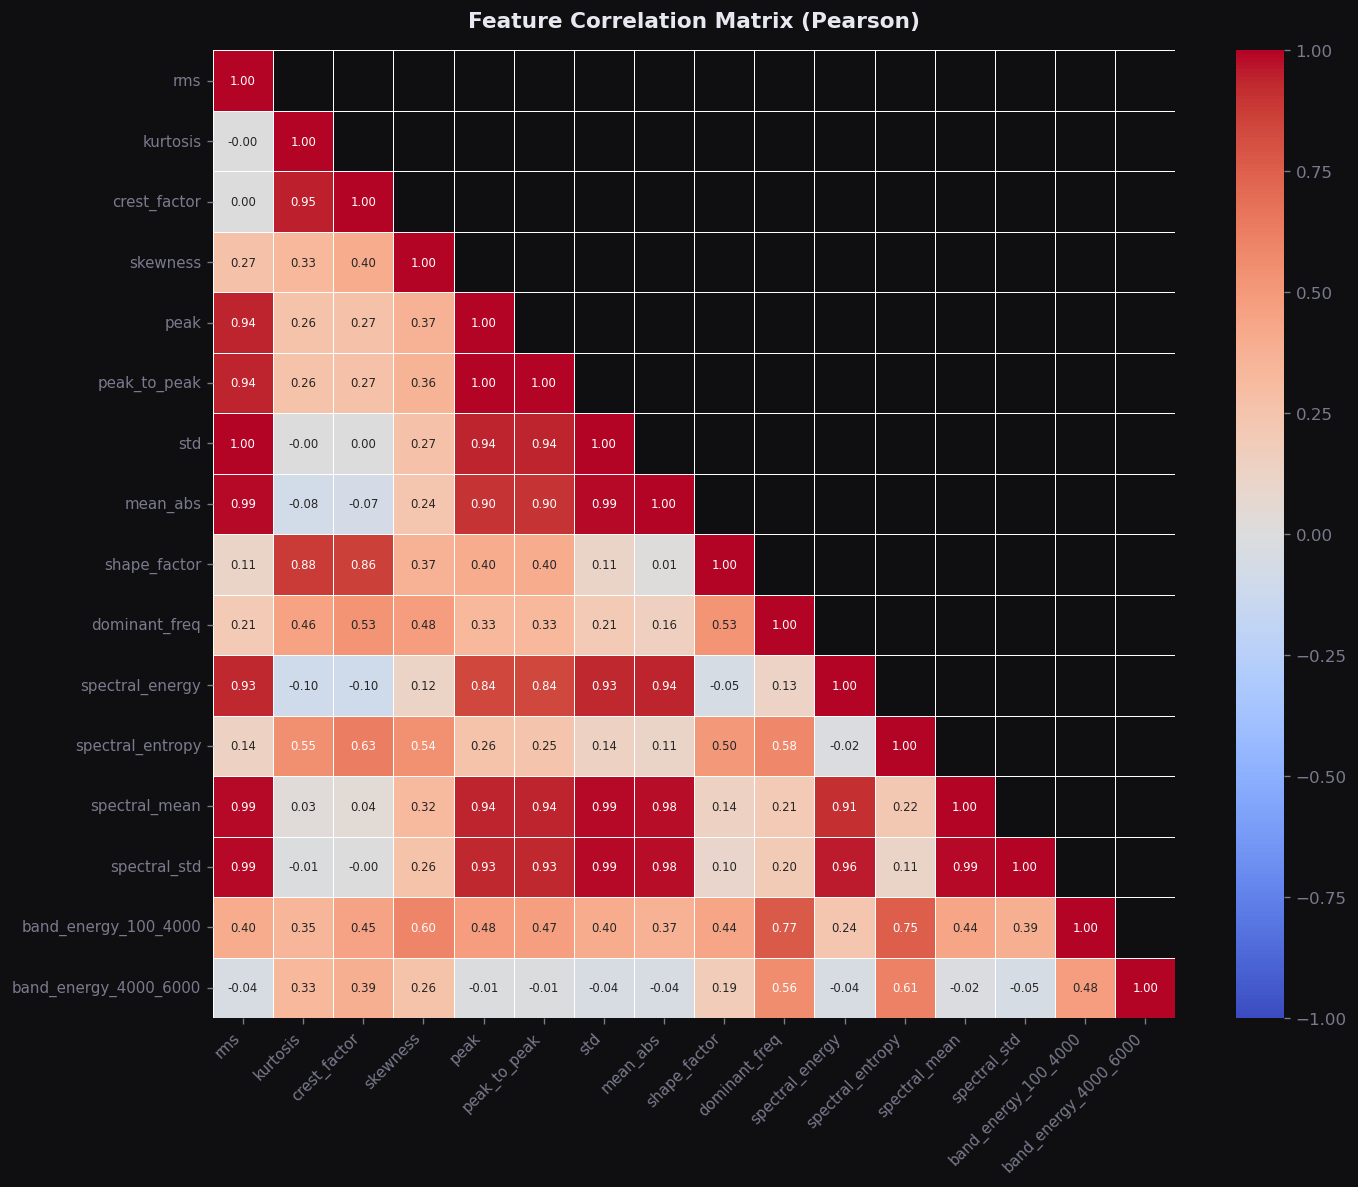

Saved → reports/14_correlation_matrix.png

── Highly Correlated Feature Pairs (|r| > 0.90) ────────────────────
  rms                    ↔  std                     r = 1.000
  peak                   ↔  peak_to_peak            r = 1.000
  rms                    ↔  mean_abs                r = 0.990
  rms                    ↔  spectral_mean           r = 0.990
  rms                    ↔  spectral_std            r = 0.990
  std                    ↔  mean_abs                r = 0.990
  std                    ↔  spectral_mean           r = 0.990
  std                    ↔  spectral_std            r = 0.990
  spectral_mean          ↔  spectral_std            r = 0.990
  mean_abs               ↔  spectral_mean           r = 0.980
  mean_abs               ↔  spectral_std            r = 0.980
  spectral_energy        ↔  spectral_std            r = 0.960
  kurtosis               ↔  crest_factor            r = 0.950
  rms                    ↔  peak                    r = 0.940
  rms               

In [9]:
corr = df_all[FEATURE_NAMES].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True   # hide upper triangle

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax
)

ax.set_title('Feature Correlation Matrix (Pearson)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='both', labelsize=9)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '14_correlation_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/14_correlation_matrix.png')

# Print highly correlated pairs (|r| > 0.90)
print()
print('── Highly Correlated Feature Pairs (|r| > 0.90) ────────────────────')
high_corr_pairs = []
for i in range(len(FEATURE_NAMES)):
    for j in range(i + 1, len(FEATURE_NAMES)):
        r = abs(corr.iloc[i, j])
        if r > 0.90:
            high_corr_pairs.append((FEATURE_NAMES[i], FEATURE_NAMES[j], r))

if high_corr_pairs:
    for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -x[2]):
        print(f'  {f1:<22} ↔  {f2:<22}  r = {r:.3f}')
    print()
    print('  These pairs carry nearly identical information.')
    
else:
    print('  No pairs above 0.90 — feature set is reasonably independent.')

---
## 7. Feature Importance Ranking (ANOVA F-score)


> **Note:** `df_all` is used for visualizations only. All model inputs use
> train data exclusively. No data leakage exists.

In [10]:
f_scores, p_values = f_classif(F_train, y_train)

importance_df = pd.DataFrame({
    'feature':  FEATURE_NAMES,
    'f_score':  f_scores,
    'p_value':  p_values,
}).sort_values('f_score', ascending=False).reset_index(drop=True)

importance_df['significant'] = importance_df['p_value'] < 0.05
importance_df['rank']        = range(1, len(importance_df) + 1)

print('── ANOVA F-Score Feature Ranking ───────────────────────────────────')
print(f'  {"Rank":<5}  {"Feature":<25}  {"F-Score":>12}  {"p-value":>12}  {"Significant"}')
print('  ' + '─' * 70)
for _, row in importance_df.iterrows():
    sig  = '✓' if row['significant'] else '✗  ← NOT significant'
    pval = f'{row["p_value"]:.2e}'
    print(f'  {int(row["rank"]):<5}  {row["feature"]:<25}  '
          f'{row["f_score"]:>12.1f}  {pval:>12}  {sig}')

── ANOVA F-Score Feature Ranking ───────────────────────────────────
  Rank   Feature                         F-Score       p-value  Significant
  ──────────────────────────────────────────────────────────────────────
  1      band_energy_100_4000             6554.8      0.00e+00  ✓
  2      spectral_entropy                 2299.6      0.00e+00  ✓
  3      shape_factor                     2181.8      0.00e+00  ✓
  4      dominant_freq                    1540.8      0.00e+00  ✓
  5      skewness                          893.4      0.00e+00  ✓
  6      crest_factor                      691.8      0.00e+00  ✓
  7      kurtosis                          541.3     3.16e-274  ✓
  8      band_energy_4000_6000             531.7     2.51e-270  ✓
  9      peak                              367.8     1.36e-199  ✓
  10     peak_to_peak                      363.0     2.03e-197  ✓
  11     spectral_mean                     239.0     3.29e-137  ✓
  12     std                               204.4     3.1

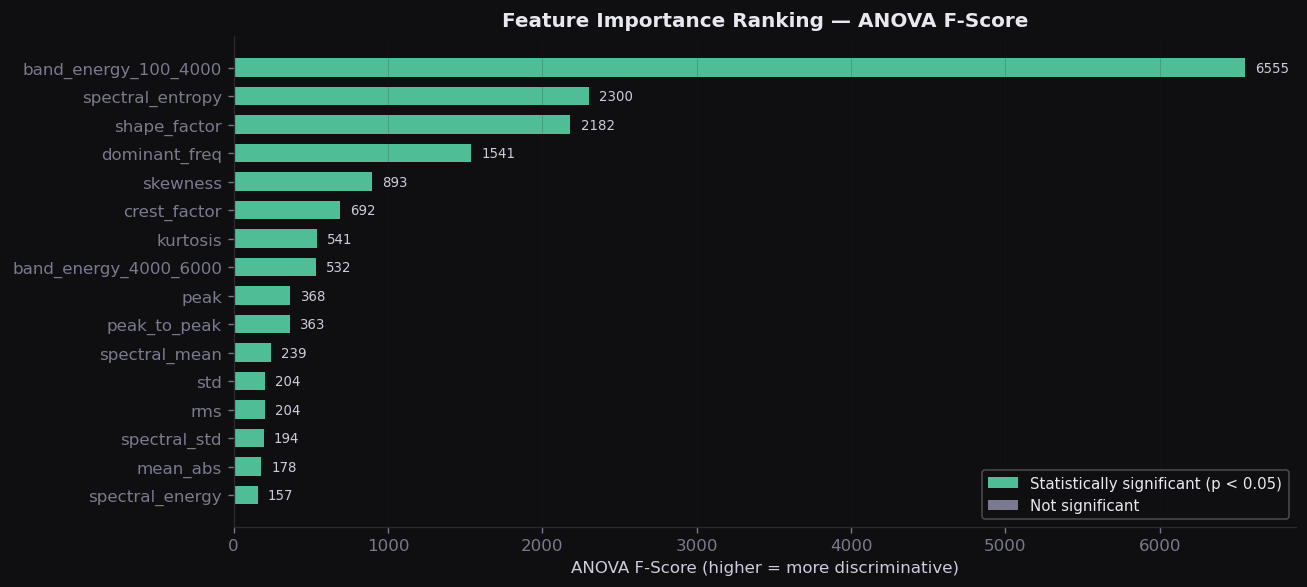

Saved → reports/15_feature_importance.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

colors_bar = [
    '#4fbe97' if row['significant'] else '#7a7a8e'
    for _, row in importance_df.iterrows()
]

bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['f_score'][::-1],
    color=colors_bar[::-1],
    edgecolor='none',
    height=0.65
)

for bar, (_, row) in zip(bars, importance_df[::-1].iterrows()):
    ax.text(bar.get_width() + importance_df['f_score'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{row["f_score"]:.0f}',
            va='center', fontsize=8, color='#ccccdd')

ax.set_xlabel('ANOVA F-Score (higher = more discriminative)', fontsize=10)
ax.set_title('Feature Importance Ranking — ANOVA F-Score',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.2)
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#4fbe97', label='Statistically significant (p < 0.05)'),
    Patch(facecolor='#7a7a8e', label='Not significant'),
], fontsize=9, framealpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '15_feature_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/15_feature_importance.png')

---
## 8. StandardScaler — Fit on Train Only



In [12]:
scaler = StandardScaler()


F_train_scaled =scaler.fit_transform(F_train)


F_test_scaled = scaler.transform(F_test)

print('── StandardScaler fitted on training set ───────────────────────────')
print(f'  Scaler mean  (first 5 features): {scaler.mean_[:5].round(4)}')
print(f'  Scaler scale (first 5 features): {scaler.scale_[:5].round(4)}')
print()


print('Post-scaling verification on training set:')
train_means = F_train_scaled.mean(axis=0)
train_stds  = F_train_scaled.std(axis=0)
print(f'  Mean range  : [{train_means.min():.6f}, {train_means.max():.6f}]  (should be ≈ 0)')
print(f'  Std  range  : [{train_stds.min():.6f}, {train_stds.max():.6f}]   (should be ≈ 1)')
print()
print('  Post-scaling verification on test set:')
test_means = F_test_scaled.mean(axis=0)
test_stds  = F_test_scaled.std(axis=0)
print(f'  Mean range  : [{test_means.min():.4f}, {test_means.max():.4f}]')
print(f'  Std  range  : [{test_stds.min():.4f}, {test_stds.max():.4f}]')
print()
print('  Note: Test mean will not be exactly 0 — that is expected and correct.')
print('  The scaler parameters come from train data only.')

── StandardScaler fitted on training set ───────────────────────────
  Scaler mean  (first 5 features): [ 3.9880e-01  3.7078e+00  4.5396e+00 -7.0000e-04  1.8128e+00]
  Scaler scale (first 5 features): [0.514  6.312  1.7133 0.1682 2.0718]

Post-scaling verification on training set:
  Mean range  : [-0.000000, 0.000000]  (should be ≈ 0)
  Std  range  : [1.000000, 1.000000]   (should be ≈ 1)

  Post-scaling verification on test set:
  Mean range  : [-0.0527, 0.0040]
  Std  range  : [0.9417, 1.0097]

  Note: Test mean will not be exactly 0 — that is expected and correct.
  The scaler parameters come from train data only.


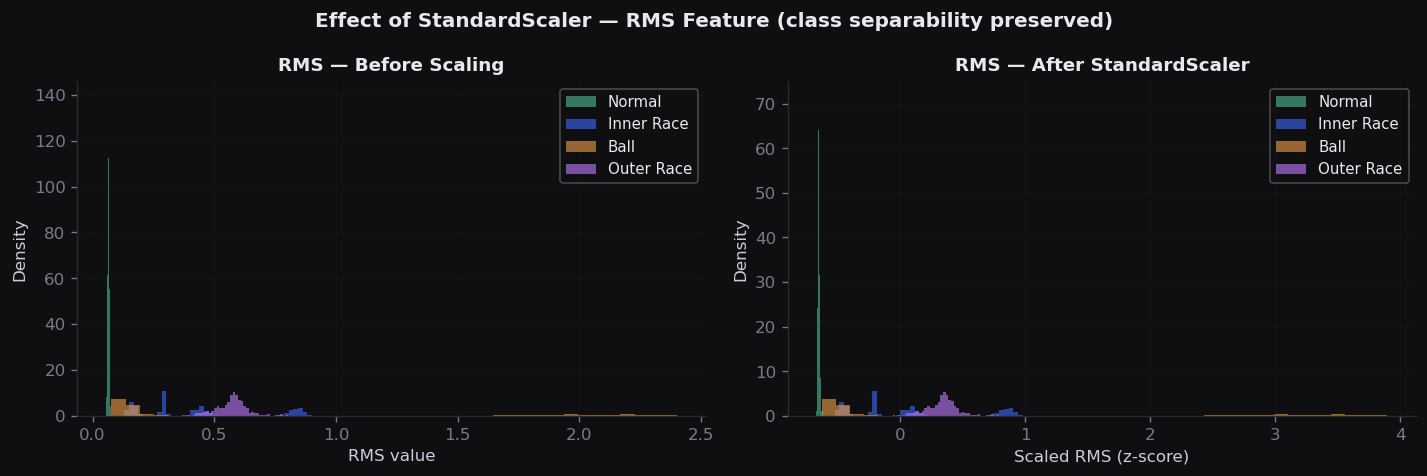

Saved → reports/16_scaling_effect.png



In [13]:
rms_idx =FEATURE_NAMES.index('rms')

fig,axes = plt.subplots(1, 2, figsize=(12, 4))

for label in [0, 1, 2, 3]:
    mask = y_train == label
    axes[0].hist(F_train[mask, rms_idx],
                 bins=40, alpha=0.6, color=CLASS_COLORS[label],
                 label=CLASS_NAMES[label], density=True)
    axes[1].hist(F_train_scaled[mask, rms_idx],
                 bins=40, alpha=0.6, color=CLASS_COLORS[label],
                 label=CLASS_NAMES[label], density=True)

axes[0].set_title('RMS — Before Scaling', fontsize=11, fontweight='bold')
axes[0].set_xlabel('RMS value')


axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9, framealpha=0.3)
axes[0].grid(True, alpha=0.2)
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].set_title('RMS — After StandardScaler', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Scaled RMS (z-score)')
axes[1].set_ylabel('Density')

axes[1].legend(fontsize=9, framealpha=0.3)
axes[1].grid(True, alpha=0.2)
axes[1].spines[['top', 'right']].set_visible(False)

fig.suptitle('Effect of StandardScaler — RMS Feature (class separability preserved)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '16_scaling_effect.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/16_scaling_effect.png')
print()


Observation: Class separation is preserved after scaling.

The distributions shift to zero-mean but their relative positions are unchanged.


---
## 9. SMOTE — Oversample Minority Classes



  After  SMOTE: Counter({np.int64(3): 756, np.int64(1): 756, np.int64(0): 756, np.int64(2): 756})
  Training set grew: 2,647 → 3,024 windows



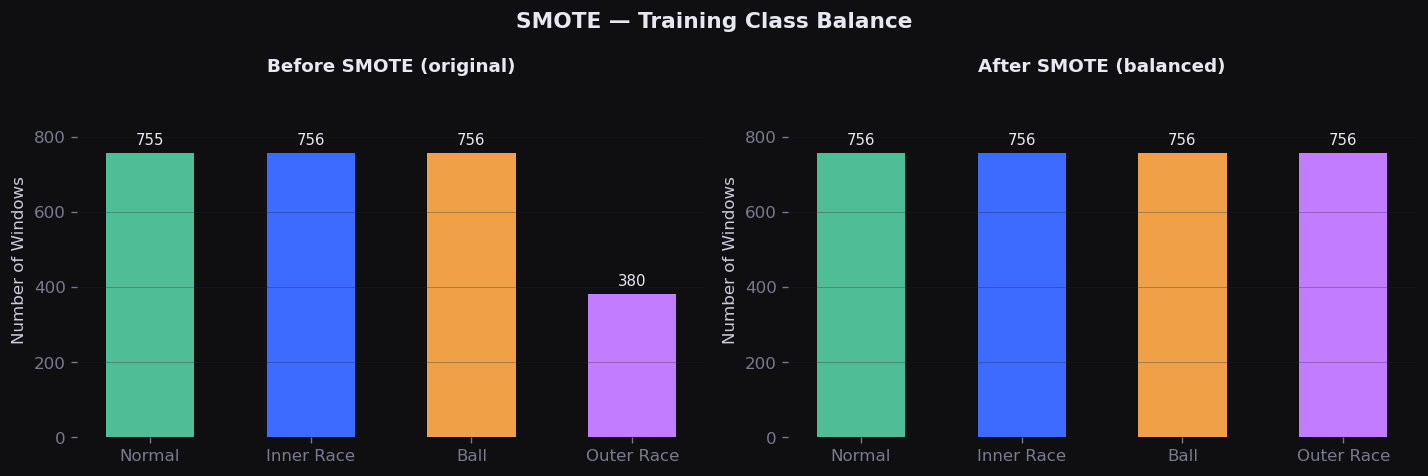

Saved → reports/17_smote_balance.png


In [14]:


    smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
    F_train_smote, y_train_smote = smote.fit_resample(F_train_scaled, y_train)

    print(f'  After  SMOTE: {Counter(y_train_smote)}')
    print(f'  Training set grew: {len(y_train):,} → {len(y_train_smote):,} windows')
    print()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, (y_arr, title) in zip(axes, [
        (y_train,       'Before SMOTE (original)'),
        (y_train_smote, 'After SMOTE (balanced)'),
    ]):
        counts = Counter(y_arr)
        labels = sorted(counts.keys())
        vals   = [counts[l] for l in labels]
        names  = [CLASS_NAMES[l] for l in labels]
        colors = [CLASS_COLORS[l] for l in labels]

        bars = ax.bar(names, vals, color=colors, edgecolor='none', width=0.55)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(vals) * 0.02,
                    f'{v:,}', ha='center', va='bottom',
                    fontsize=9, color='#e8e8f0')

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_ylabel('Number of Windows')
        ax.set_ylim(0, max(vals) * 1.25)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

    fig.suptitle('SMOTE — Training Class Balance',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, '17_smote_balance.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/17_smote_balance.png')


---
## 10. PCA Visualisation — 2D Separability Check



PCA explained variance:
  PC1: 51.5%
  PC2: 27.9%
  Total: 79.4% of variance captured in 2D


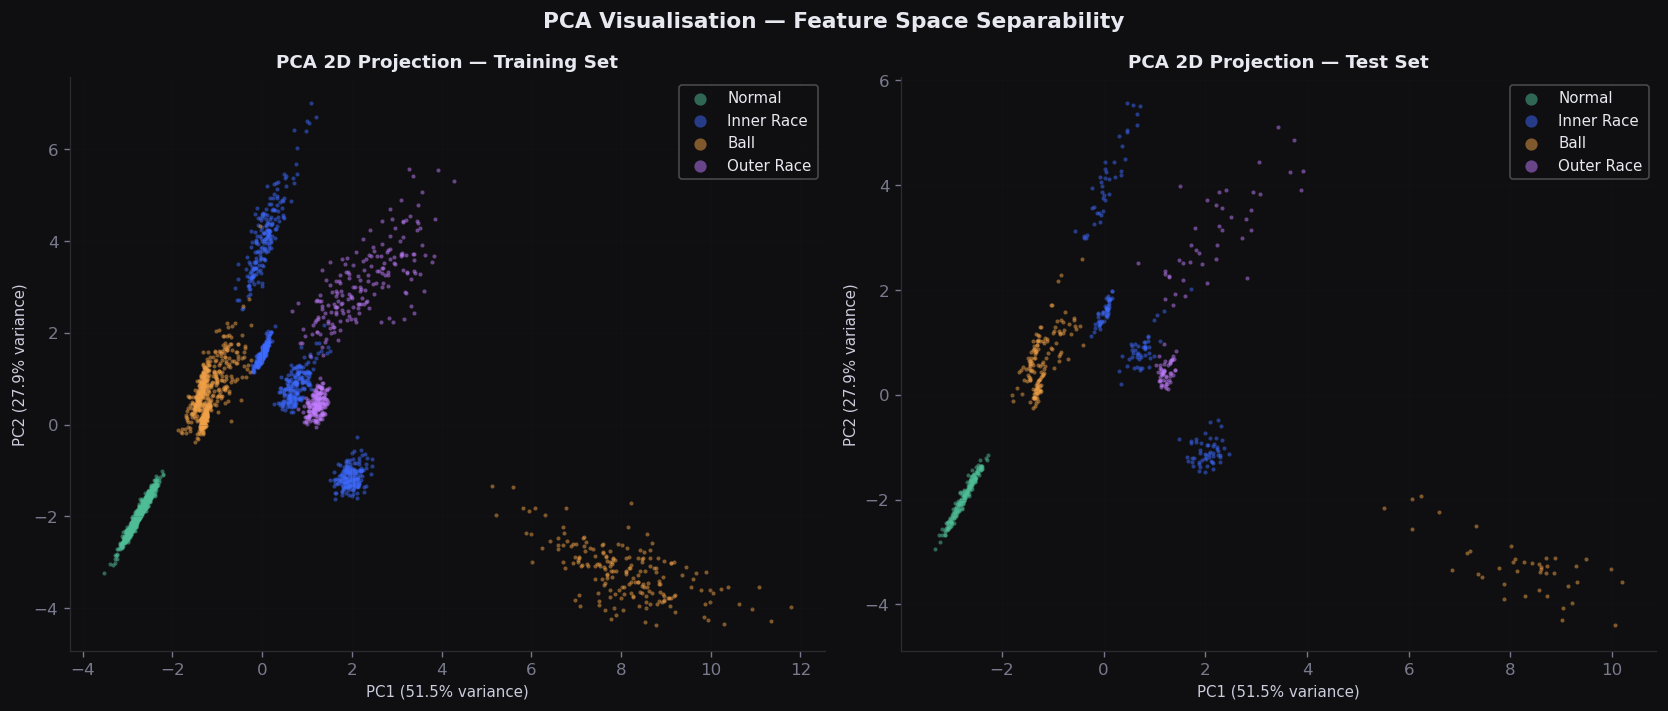

Saved → reports/18_pca_2d.png


In [15]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
F_train_2d = pca.fit_transform(F_train_scaled)
F_test_2d  = pca.transform(F_test_scaled)

explained = pca.explained_variance_ratio_
print(f'PCA explained variance:')
print(f'  PC1: {explained[0]*100:.1f}%')
print(f'  PC2: {explained[1]*100:.1f}%')
print(f'  Total: {sum(explained)*100:.1f}% of variance captured in 2D')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (F_2d, y_arr, split_title) in zip(axes, [
    (F_train_2d, y_train, 'Training Set'),
    (F_test_2d,  y_test,  'Test Set'),
]):
    for label in [0, 1, 2, 3]:
        mask = y_arr == label
        ax.scatter(
            F_2d[mask, 0], F_2d[mask, 1],
            c=CLASS_COLORS[label],
            label=CLASS_NAMES[label],
            s=6, alpha=0.5, linewidths=0
        )

    ax.set_title(f'PCA 2D Projection — {split_title}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=9)
    ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=9)
    ax.legend(fontsize=9, framealpha=0.3, markerscale=3)
    ax.grid(True, alpha=0.15)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('PCA Visualisation — Feature Space Separability',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, '18_pca_2d.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/18_pca_2d.png')



In [16]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_NAMES,
    columns=['PC1', 'PC2']
).round(3)

loadings['abs_PC1'] = loadings['PC1'].abs()
loadings = loadings.sort_values('abs_PC1', ascending=False)

print('── PCA Loadings — Top Features Driving PC1 and PC2 ─────────────────')
print(f'  {"Feature":<25}  {"PC1":>8}  {"PC2":>8}')
print('  ' + '─' * 44)
for feat, row in loadings.iterrows():
    print(f'  {feat:<25}  {row["PC1"]:>8.3f}  {row["PC2"]:>8.3f}')

print()
top_pc1 = loadings.index[0]
print(f'  PC1 is dominated by: {top_pc1}')
print(f'  This means PC1 separates classes primarily by {top_pc1} — consistent with EDA.')

── PCA Loadings — Top Features Driving PC1 and PC2 ─────────────────
  Feature                         PC1       PC2
  ────────────────────────────────────────────
  peak_to_peak                  0.339    -0.025
  peak                          0.339    -0.022
  spectral_mean                 0.335    -0.110
  rms                           0.333    -0.135
  std                           0.333    -0.135
  spectral_std                  0.331    -0.142
  mean_abs                      0.323    -0.165
  spectral_energy               0.300    -0.194
  band_energy_100_4000          0.206     0.266
  skewness                      0.155     0.230
  dominant_freq                 0.148     0.315
  spectral_entropy              0.123     0.358
  shape_factor                  0.117     0.353
  crest_factor                  0.089     0.405
  kurtosis                      0.080     0.384
  band_energy_4000_6000         0.043     0.282

  PC1 is dominated by: peak_to_peak
  This means PC1 separates clas

---
## 11. Save Feature Matrices

In [17]:
save_map = {
    'F_train_scaled.npy':  F_train_scaled,    # scaled, pre-SMOTE train features
    'F_test_scaled.npy':   F_test_scaled,     # scaled test features (never SMOTEd)
    'F_train_smote.npy':   F_train_smote,     # scaled + SMOTEd train features
    'y_train_smote.npy':   y_train_smote,     # labels after SMOTE
    'F_train_raw.npy':     F_train,           # unscaled train features (for inspection)
    'F_test_raw.npy':      F_test,            # unscaled test features
}

for fname, arr in save_map.items():
    path = os.path.join(PROCESSED_DIR, fname)
    np.save(path, arr)
    print(f'  ✓ {fname:<28}  shape={str(arr.shape):<22}  {arr.nbytes/1024:.1f} KB')

df_train_out        = pd.DataFrame(F_train, columns=FEATURE_NAMES)
df_train_out['label'] = y_train
df_train_out.to_csv(os.path.join(PROCESSED_DIR, 'features_train.csv'), index=False)

df_test_out         = pd.DataFrame(F_test, columns=FEATURE_NAMES)
df_test_out['label'] = y_test
df_test_out.to_csv(os.path.join(PROCESSED_DIR, 'features_test.csv'), index=False)

print(f'  ✓ features_train.csv')
print(f'  ✓ features_test.csv')

scaler_path = os.path.join(PROJECT_ROOT, 'models', 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'  ✓ scaler.pkl  saved to models/ (load this in notebook 04 to scale new data)')

importance_df.to_csv(
    os.path.join(PROCESSED_DIR, 'feature_importance.csv'), index=False)
print(f'  ✓ feature_importance.csv')

print()
print(f'All saved to: {PROCESSED_DIR}')

  ✓ F_train_scaled.npy            shape=(2647, 16)              330.9 KB
  ✓ F_test_scaled.npy             shape=(662, 16)               82.8 KB
  ✓ F_train_smote.npy             shape=(3024, 16)              378.0 KB
  ✓ y_train_smote.npy             shape=(3024,)                 23.6 KB
  ✓ F_train_raw.npy               shape=(2647, 16)              330.9 KB
  ✓ F_test_raw.npy                shape=(662, 16)               82.8 KB
  ✓ features_train.csv
  ✓ features_test.csv
  ✓ scaler.pkl  saved to models/ (load this in notebook 04 to scale new data)
  ✓ feature_importance.csv

All saved to: C:\Users\My Pc\Downloads\predictive-maintenance\data\processed


In [18]:
scaler_path = os.path.join(PROJECT_ROOT, 'models', 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f'✓ Scaler saved → {scaler_path}')

✓ Scaler saved → C:\Users\My Pc\Downloads\predictive-maintenance\models\scaler.pkl


---
## 12. Summary & Next Steps



**FEATURE SET**
  Total features     : 16
  Time-domain (9)    : rms, kurtosis, crest_factor, skewness,
                       peak, peak_to_peak, std, mean_abs, shape_factor
  Frequency-domain (7): dominant_freq, spectral_energy, spectral_entropy,
                        spectral_mean, spectral_std,
                        band_energy_100_4000, band_energy_4000_6000
  Hanning window     : applied inside frequency_domain_features() ✓

**DATASET SIZES**
  Train (scaled)     : (2647, 16)
  Train (SMOTE)      : (3024, 16)
  Test  (scaled)     : (662, 16)

**KEY FINDINGS**
  Top 3 features     : ['band_energy_100_4000', 'spectral_entropy', 'shape_factor']
  Weak features (<median F): ['peak', 'peak_to_peak', 'spectral_mean', 'std', 'rms', 'spectral_std', 'mean_abs', 'spectral_energy']
  PCA 2D variance    : 79.4%

**SAVED FILES**
  data/processed/F_train_scaled.npy
  data/processed/F_test_scaled.npy
  data/processed/F_train_smote.npy
  data/processed/y_train_smote.npy
  data/processed/F_train_raw.npy
  data/processed/F_test_raw.npy
  data/processed/features_train.csv
  data/processed/features_test.csv
  data/processed/scaler.pkl
  data/processed/feature_importance.csv




In [19]:
# the EXACT training column order


df = pd.read_csv(os.path.join(PROCESSED_DIR, 'features_train.csv'))
feature_cols = [c for c in df.columns if c != 'label']

print('EXACT TRAINING FEATURE ORDER:')
for i, f in enumerate(feature_cols):
    print(f'  {i:>2}. {f}')

EXACT TRAINING FEATURE ORDER:
   0. rms
   1. kurtosis
   2. crest_factor
   3. skewness
   4. peak
   5. peak_to_peak
   6. std
   7. mean_abs
   8. shape_factor
   9. dominant_freq
  10. spectral_energy
  11. spectral_entropy
  12. spectral_mean
  13. spectral_std
  14. band_energy_100_4000
  15. band_energy_4000_6000
